In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split
from torch.nn.parameter import Parameter
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import adjusted_rand_score

In [ ]:
MODEL_NAME = "DCEC_2"
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 30
NUM_CLUSTERS = 10
ALPHA = 1
GAMMA = 0.1

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Transforms
transform = transforms.ToTensor()

# Train loader
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=False)

# Test loader
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
class Reshape(nn.Module):
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape  # this should be the target shape without the batch dim (e.g. (32, 7, 7))

    def forward(self, x):
        return x.view(x.size(0), *self.shape)

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1), # 32 x 14 x 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 64 x 7 x 7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 x 3 x 3
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*3*3, 10), # Latent Rep dim. 10
        )

        self.decoder = nn.Sequential(
            nn.Linear(10, 128*3*3),
            nn.ReLU(),
            Reshape(128, 3, 3),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=1), # 64 x 7 x 7
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 32 x 14 x 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # 1 x 28 x 28
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

class ClusteringLayer(nn.Module):
    def __init__(self, n_clusters=NUM_CLUSTERS, cluster_centers=None, alpha=ALPHA):
        super(ClusteringLayer, self).__init__()
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.cluster_centers = Parameter(cluster_centers) # Cluster centres are updated during training
    
    def forward(self, x):
        norm_squared = torch.sum((x.unsqueeze(1) - self.cluster_centers)**2, 2)
        numerator = 1.0 / (1.0 + (norm_squared / self.alpha))
        power = float(self.alpha + 1) / 2
        numerator = numerator**power
        t_dist = (numerator.t() / torch.sum(numerator, 1)).t()  # soft assignment using t-distribution
        return t_dist
    
class DEC(nn.Module):
    def __init__(self, n_clusters=NUM_CLUSTERS, autoencoder=None, cluster_centres=None, alpha=ALPHA):
        super(DEC, self).__init__()
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.cluster_centres = cluster_centres
        self.autoencoder = autoencoder
        self.clusteringlayer = ClusteringLayer(self.n_clusters, self.cluster_centres, self.alpha)
    
    def target_distribution(self, q_):
        weight = (q_ ** 2) / torch.sum(q_, 0)
        return (weight.t() / torch.sum(weight, 1)).t()
    
    def forward(self, x):
        encoded = self.autoencoder.encoder(x)
        soft_ass = self.clusteringlayer(encoded)
        decoded = self.autoencoder.decoder(encoded)
        return soft_ass, decoded

In [6]:
loaded_checkpoint = torch.load(r"C:\Users\ea197\Projects\Literature-Review-ML\DCEC_MNIST\DCEC_2_final.pth", map_location=device)

model_AE = Autoencoder().to(device)

dummy_centers = torch.randn(NUM_CLUSTERS, 10).to(device)

model_DEC = DEC(n_clusters=NUM_CLUSTERS, autoencoder=model_AE, cluster_centres=dummy_centers, alpha=ALPHA).to(device)

model_DEC.load_state_dict(loaded_checkpoint["model_state"])

C:\Users\ea197\AppData\Local\Temp\ipykernel_23236\1679507673.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_checkpoint = torch.load(r"C:\Users\ea197\Projects\Lit

<All keys matched successfully>

Test Samples

In [7]:
all_latents = []
all_labels = []  # optional: to compare clusters with true digits

with torch.no_grad():
    for img, labels in test_loader:
        img = img.to(device)
        
        latent = model_DEC.autoencoder.encoder(img)
        
        all_latents.append(latent.cpu().numpy())
        all_labels.append(labels.numpy())

# Stack into big arrays
all_latents = np.concatenate(all_latents, axis=0)  # shape: (num_test_samples, 10)
all_labels = np.concatenate(all_labels, axis=0)    # shape: (num_test_samples,)

In [8]:
print(all_latents)

[[-12.555938   -11.5906925   -0.7875991  ...   2.2127976  -15.433227
   -0.65439206]
 [-10.131027   -12.495461     0.69428533 ... -17.067104     5.7562513
    1.0983865 ]
 [ -8.443655    10.932126    -8.64133    ... -20.69254      8.141799
    8.5513    ]
 ...
 [-13.509101     3.127886   -12.249879   ...   7.6264195   -4.378621
    7.0194893 ]
 [  4.9591107    7.2380652   -8.968869   ...  -6.463615    -0.9085231
    3.6394315 ]
 [ -1.6241744   16.600235     7.712902   ...  -9.901123    -1.5200396
    2.0303152 ]]


In [9]:
np.shape(all_latents)

(10000, 10)

In [10]:
print(all_labels)

[7 2 1 ... 4 5 6]


In [11]:
np.shape(all_labels)

(10000,)

In [12]:
cluster_range = range(2, 15)  # try clusters from 2 to 14
ch_scores = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    cluster_labels = kmeans.fit_predict(all_latents)
    ch_score = calinski_harabasz_score(all_latents, cluster_labels)
    ch_scores.append(ch_score)
    print(f"k = {k}, Calinski-Harabasz Score = {ch_score:.2f}")

k = 2, Calinski-Harabasz Score = 2966.32
k = 3, Calinski-Harabasz Score = 3592.02
k = 4, Calinski-Harabasz Score = 2426.98
k = 5, Calinski-Harabasz Score = 3641.08
k = 6, Calinski-Harabasz Score = 5716.72
k = 7, Calinski-Harabasz Score = 9484.25
k = 8, Calinski-Harabasz Score = 15660.54
k = 9, Calinski-Harabasz Score = 17078.93
k = 10, Calinski-Harabasz Score = 52280.02
k = 11, Calinski-Harabasz Score = 49010.07
k = 12, Calinski-Harabasz Score = 46538.43
k = 13, Calinski-Harabasz Score = 44909.13
k = 14, Calinski-Harabasz Score = 42979.02


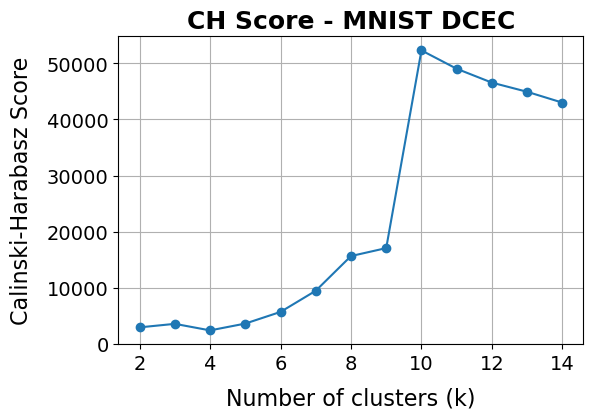

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(cluster_range, ch_scores, marker="o")
plt.xlabel("Number of clusters (k)", fontsize=16, labelpad=10)
plt.ylabel("Calinski-Harabasz Score", fontsize=16, labelpad=10)
plt.title("CH Score - MNIST DCEC", fontsize=18, fontweight="bold")
plt.tick_params(axis='both', labelsize=14)
plt.grid(True)
plt.savefig("ch_score_mnist_dcec.pdf", bbox_inches="tight")
plt.show()

In [14]:
cluster_range = range(2, 15)  # same as before
inertias = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(all_latents)
    inertias.append(kmeans.inertia_)  # SSE within clusters
    print(f"k = {k}, inertia = {kmeans.inertia_:.2f}")

k = 2, inertia = 4987345.00
k = 3, inertia = 3762930.50
k = 4, inertia = 3741677.50
k = 5, inertia = 2631918.75
k = 6, inertia = 1675368.00
k = 7, inertia = 966018.56
k = 8, inertia = 540219.25
k = 9, inertia = 440671.00
k = 10, inertia = 134452.52
k = 11, inertia = 129175.45
k = 12, inertia = 123762.28
k = 13, inertia = 117665.84
k = 14, inertia = 113554.45


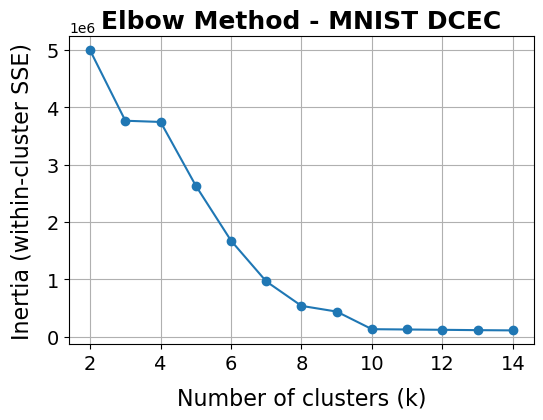

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(cluster_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)", fontsize=16, labelpad=10)
plt.ylabel("Inertia (within-cluster SSE)", fontsize=16, labelpad=10)
plt.title("Elbow Method - MNIST DCEC", fontsize=18, fontweight="bold")
plt.tick_params(axis='both', labelsize=14)
plt.grid(True)
plt.savefig("elbow_mnist_dcec.pdf", bbox_inches="tight")
plt.show()

In [17]:
optimal_k = 10  # for example, based on elbow + CH

kmeans = KMeans(n_clusters=optimal_k, n_init=20)
cluster_ids = kmeans.fit_predict(all_latents)

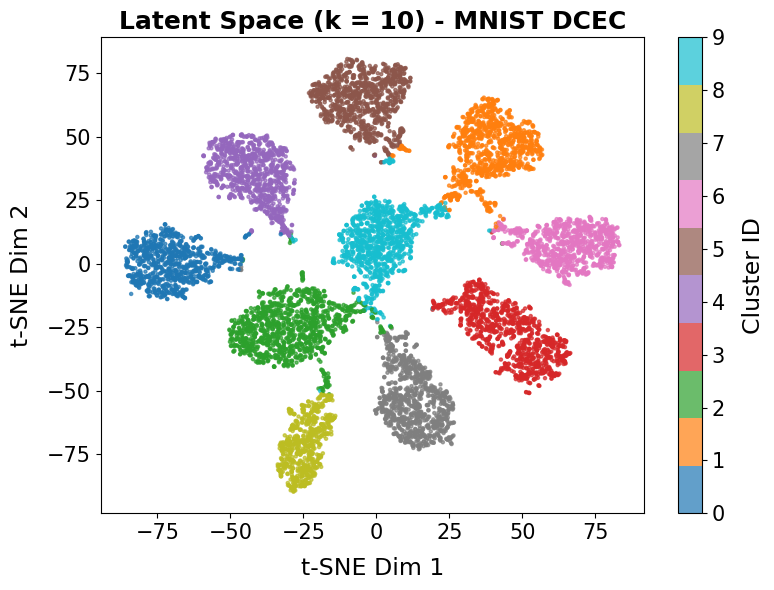

In [19]:
tsne = TSNE(n_components=2, random_state=0)
latents_2d = tsne.fit_transform(all_latents)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latents_2d[:, 0],
    latents_2d[:, 1],
    c=cluster_ids,
    cmap="tab10",
    s=5,
    alpha=0.7
)
cbar = plt.colorbar(scatter, ticks=range(optimal_k))
cbar.set_label("Cluster ID", fontsize=17, labelpad=12)
cbar.ax.tick_params(labelsize=15)
plt.title(f"Latent Space (k = {optimal_k}) - MNIST DCEC", fontsize=18, fontweight="bold")
plt.xlabel("t-SNE Dim 1", fontsize=17, labelpad=10)
plt.ylabel("t-SNE Dim 2", fontsize=17, labelpad=10)
plt.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.savefig("latent_space_mnist_dcec.pdf", bbox_inches="tight")
plt.show()

In [20]:
nmi_score = normalized_mutual_info_score(all_labels, cluster_ids)
print(f"NMI: {nmi_score:.4f}")

NMI: 0.8184


In [21]:
ari = adjusted_rand_score(all_labels, cluster_ids)
print(f"ARI: {ari:.4f}")

ARI: 0.7610


Training Samples

In [22]:
all_latents_train = []
all_labels_train = []  # optional: to compare clusters with true digits

with torch.no_grad():
    for img, labels in train_loader:
        img = img.to(device)
        
        latent = model_DEC.autoencoder.encoder(img)
        
        all_latents_train.append(latent.cpu().numpy())
        all_labels_train.append(labels.numpy())

# Stack into big arrays
all_latents_train = np.concatenate(all_latents_train, axis=0)  # shape: (num_train_samples, 10)
all_labels_train = np.concatenate(all_labels_train, axis=0)    # shape: (num_train_samples,)

In [23]:
print(all_latents_train)

[[  5.3671436    6.4790196   -6.765333   ...  -7.30531     -1.6976565
    3.238803  ]
 [ -8.325606     2.9474995    9.796508   ...  11.95542      1.8280475
   -7.923728  ]
 [ -6.16046     -0.42518058 -15.491262   ...   9.407399    -2.7863693
   -9.210454  ]
 ...
 [  6.8532004    7.048222    -8.041907   ...  -7.0206065   -1.3129786
    3.1516273 ]
 [ -0.92738503  18.364988     9.962775   ...  -8.8634      -1.1871426
    2.1600986 ]
 [ -4.3118825    0.06127134  -7.4585924  ...  -3.224324     1.0982951
    1.5120196 ]]


In [24]:
np.shape(all_latents_train)

(60000, 10)

In [25]:
print(all_labels_train)

[5 0 4 ... 5 6 8]


In [26]:
np.shape(all_labels_train)

(60000,)

In [27]:
cluster_range = range(2, 15)  # try clusters from 2 to 14
ch_scores = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    cluster_labels = kmeans.fit_predict(all_latents_train)
    ch_score = calinski_harabasz_score(all_latents_train, cluster_labels)
    ch_scores.append(ch_score)
    print(f"k = {k}, Calinski-Harabasz Score = {ch_score:.2f}")

k = 2, Calinski-Harabasz Score = 5449.21
k = 3, Calinski-Harabasz Score = 10306.48
k = 4, Calinski-Harabasz Score = 14488.75
k = 5, Calinski-Harabasz Score = 20043.76
k = 6, Calinski-Harabasz Score = 42066.62
k = 7, Calinski-Harabasz Score = 77241.02
k = 8, Calinski-Harabasz Score = 120301.24
k = 9, Calinski-Harabasz Score = 229671.30
k = 10, Calinski-Harabasz Score = 397194.47
k = 11, Calinski-Harabasz Score = 372618.47
k = 12, Calinski-Harabasz Score = 349822.62
k = 13, Calinski-Harabasz Score = 329669.88
k = 14, Calinski-Harabasz Score = 317491.44


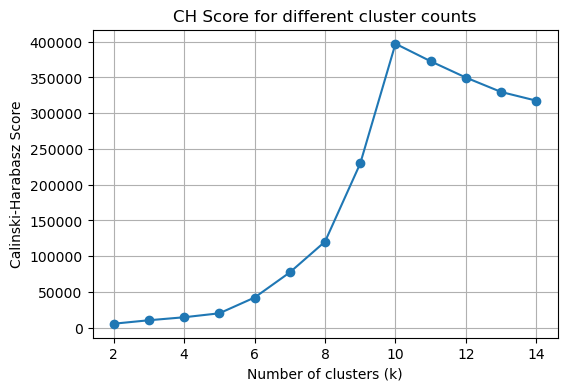

In [28]:
plt.figure(figsize=(6, 4))
plt.plot(cluster_range, ch_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("CH Score for different cluster counts")
plt.grid(True)
plt.show()

In [29]:
cluster_range = range(2, 15)  # same as before
inertias = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(all_latents_train)
    inertias.append(kmeans.inertia_)  # SSE within clusters
    print(f"k = {k}, inertia = {kmeans.inertia_:.2f}")

k = 2, inertia = 35640680.00
k = 3, inertia = 28936174.00
k = 4, inertia = 22544500.00
k = 5, inertia = 16640267.00
k = 6, inertia = 8628169.00
k = 7, inertia = 4455890.50
k = 8, inertia = 2585463.75
k = 9, inertia = 1229239.12
k = 10, inertia = 641661.31
k = 11, inertia = 615986.56
k = 12, inertia = 596768.56
k = 13, inertia = 580712.38
k = 14, inertia = 556941.81


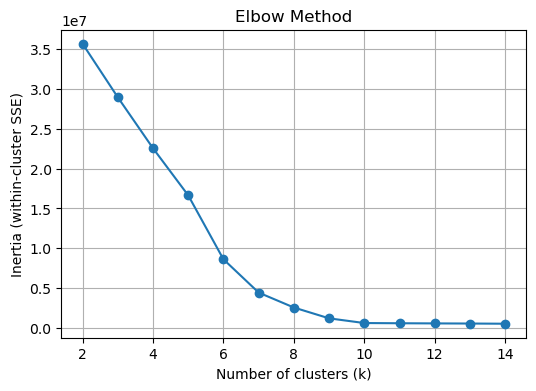

In [30]:
plt.figure(figsize=(6, 4))
plt.plot(cluster_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [31]:
optimal_k = 10  # for example, based on elbow + CH

kmeans = KMeans(n_clusters=optimal_k, n_init=20)
cluster_ids = kmeans.fit_predict(all_latents_train)

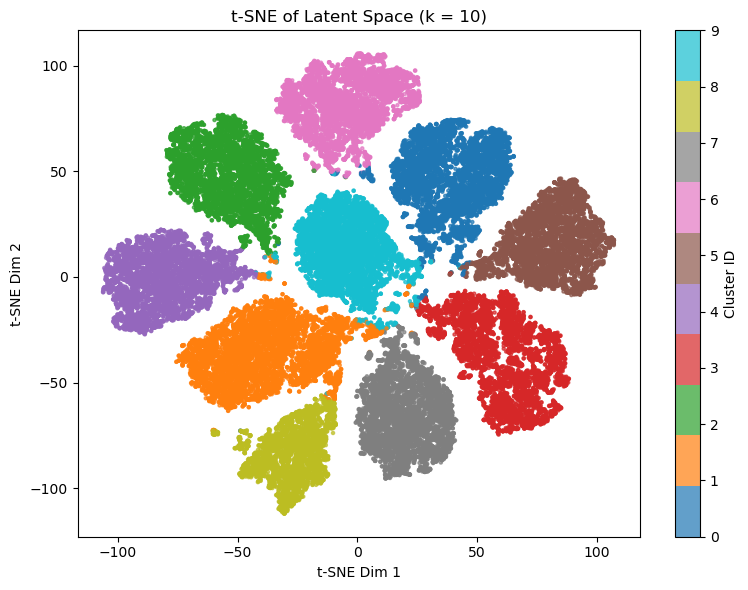

In [32]:
tsne = TSNE(n_components=2)
latents_2d = tsne.fit_transform(all_latents_train)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latents_2d[:, 0],
    latents_2d[:, 1],
    c=cluster_ids,
    cmap="tab10",
    s=5,
    alpha=0.7
)
plt.colorbar(scatter, ticks=range(optimal_k), label="Cluster ID")
plt.title(f"t-SNE of Latent Space (k = {optimal_k})")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.tight_layout()
plt.show()

In [33]:
nmi_score = normalized_mutual_info_score(all_labels_train, cluster_ids)
print(f"NMI: {nmi_score:.4f}")

NMI: 0.8150


In [34]:
ari = adjusted_rand_score(all_labels_train, cluster_ids)
print(f"ARI: {ari:.4f}")

ARI: 0.7581
